In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
print("Current folder:")
print(os.getcwd())

print("\nMain files:")
print(os.listdir())

Current folder:
c:\Users\daghe\OneDrive\Desktop\ADHD Data

Main files:
['.venv', 'Data Dictionary.xlsx', 'Models.ipynb', 'SAMPLE_SUBMISSION.xlsx', 'TEST', 'TRAIN_NEW', 'TRAIN_OLD']


In [3]:
print("Files inside TRAIN_NEW:")

for file in os.listdir("TRAIN_NEW"):
    print(file)

Files inside TRAIN_NEW:
TRAINING_SOLUTIONS.xlsx
TRAIN_CATEGORICAL_METADATA_new.xlsx
TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv
TRAIN_QUANTITATIVE_METADATA_new.xlsx


In [4]:
train_files = os.listdir("TRAIN_NEW")

categorical_file = None
quantitative_file = None
solutions_file = None

for file in train_files:

    name = file.lower()

    if "categorical" in name:
        categorical_file = os.path.join(
            "TRAIN_NEW",
            file
        )

    elif "quantitative" in name:
        quantitative_file = os.path.join(
            "TRAIN_NEW",
            file
        )

    elif "solution" in name:
        solutions_file = os.path.join(
            "TRAIN_NEW",
            file
        )

print("Categorical:", categorical_file)
print("Quantitative:", quantitative_file)
print("Solutions:", solutions_file)

Categorical: TRAIN_NEW\TRAIN_CATEGORICAL_METADATA_new.xlsx
Quantitative: TRAIN_NEW\TRAIN_QUANTITATIVE_METADATA_new.xlsx
Solutions: TRAIN_NEW\TRAINING_SOLUTIONS.xlsx


In [5]:
print(
    "Categorical exists:",
    os.path.exists(categorical_file)
)

print(
    "Quantitative exists:",
    os.path.exists(quantitative_file)
)

print(
    "Solutions exists:",
    os.path.exists(solutions_file)
)

Categorical exists: True
Quantitative exists: True
Solutions exists: True


In [6]:
print("categorical_file =", categorical_file)
print("quantitative_file =", quantitative_file)
print("solutions_file =", solutions_file)

categorical_file = TRAIN_NEW\TRAIN_CATEGORICAL_METADATA_new.xlsx
quantitative_file = TRAIN_NEW\TRAIN_QUANTITATIVE_METADATA_new.xlsx
solutions_file = TRAIN_NEW\TRAINING_SOLUTIONS.xlsx


In [7]:
import openpyxl
print(openpyxl.__version__)

3.1.5


In [8]:
categorical = pd.read_excel(
    categorical_file,
    engine="openpyxl"
)

print(categorical.shape)
categorical.head()

(1213, 10)


,participant_id,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ
0,00aIpNTbG5uh,2019,4,1.0,0.0,3.0,21.0,45.0,NaN,NaN
1,00fV0OyyoLfw,2017,1,0.0,9.0,2.0,21.0,0.0,21.0,45.0
2,04X1eiS79T4B,2017,1,1.0,2.0,2.0,9.0,0.0,NaN,NaN
3,05ocQutkURd6,2018,1,3.0,8.0,2.0,18.0,10.0,18.0,0.0
4,06YUNBA9ZRLq,2018,1,0.0,1.0,2.0,12.0,0.0,NaN,NaN


In [9]:
quantitative = pd.read_excel(
    quantitative_file,
    engine="openpyxl"
)

targets = pd.read_excel(
    solutions_file,
    engine="openpyxl"
)

In [10]:
print(os.listdir("TRAIN_NEW"))

['TRAINING_SOLUTIONS.xlsx', 'TRAIN_CATEGORICAL_METADATA_new.xlsx', 'TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv', 'TRAIN_QUANTITATIVE_METADATA_new.xlsx']


In [11]:
categorical_file = "TRAIN_NEW/TRAIN_CATEGORICAL_METADATA_new.xlsx"
quantitative_file = "TRAIN_NEW/TRAIN_QUANTITATIVE_METADATA_new.xlsx"
solutions_file = "TRAIN_NEW/TRAINING_SOLUTIONS.xlsx"

In [12]:
categorical = pd.read_excel(
    categorical_file,
    engine="openpyxl"
)

quantitative = pd.read_excel(
    quantitative_file,
    engine="openpyxl"
)

targets = pd.read_excel(
    solutions_file,
    engine="openpyxl"
)

In [13]:
print("Categorical shape:", categorical.shape)
print("Quantitative shape:", quantitative.shape)
print("Targets shape:", targets.shape)

Categorical shape: (1213, 10)
Quantitative shape: (1213, 19)
Targets shape: (1213, 3)


In [14]:
categorical.head()

,participant_id,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ
0,00aIpNTbG5uh,2019,4,1.0,0.0,3.0,21.0,45.0,NaN,NaN
1,00fV0OyyoLfw,2017,1,0.0,9.0,2.0,21.0,0.0,21.0,45.0
2,04X1eiS79T4B,2017,1,1.0,2.0,2.0,9.0,0.0,NaN,NaN
3,05ocQutkURd6,2018,1,3.0,8.0,2.0,18.0,10.0,18.0,0.0
4,06YUNBA9ZRLq,2018,1,0.0,1.0,2.0,12.0,0.0,NaN,NaN


In [15]:
quantitative.head()

,participant_id,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
0,00aIpNTbG5uh,100.00,13.0,3.0,15.0,44.0,14.0,20.0,27.0,3.0,17.0,4.0,11.0,5.0,8.0,6.0,2.0,9.0,14.274127
1,00fV0OyyoLfw,92.27,14.0,3.0,12.0,35.0,25.0,28.0,30.0,5.0,20.0,4.0,13.0,5.0,8.0,7.0,3.0,8.0,NaN
2,04X1eiS79T4B,86.67,14.0,3.0,21.0,37.0,18.0,26.0,28.0,3.0,24.0,7.0,10.0,10.0,7.0,14.0,7.0,7.0,13.463381
3,05ocQutkURd6,93.34,14.0,3.0,11.0,42.0,15.0,20.0,28.0,0.0,5.0,0.0,3.0,0.0,3.0,2.0,2.0,6.0,9.572553
4,06YUNBA9ZRLq,0.00,14.0,8.0,12.0,35.0,22.0,12.0,24.0,6.0,23.0,7.0,15.0,8.0,9.0,8.0,1.0,4.0,6.654574


In [16]:
targets.head()

,participant_id,ADHD_Outcome,Sex_F
0,UmrK0vMLopoR,1,1
1,CPaeQkhcjg7d,1,0
2,Nb4EetVPm3gs,1,0
3,p4vPhVu91o4b,1,1
4,M09PXs7arQ5E,1,1


In [17]:
print("Categorical columns:")
print(categorical.columns.tolist())

Categorical columns:
['participant_id', 'Basic_Demos_Enroll_Year', 'Basic_Demos_Study_Site', 'PreInt_Demos_Fam_Child_Ethnicity', 'PreInt_Demos_Fam_Child_Race', 'MRI_Track_Scan_Location', 'Barratt_Barratt_P1_Edu', 'Barratt_Barratt_P1_Occ', 'Barratt_Barratt_P2_Edu', 'Barratt_Barratt_P2_Occ']


In [18]:
print("Quantitative columns:")
print(quantitative.columns.tolist())

Quantitative columns:
['participant_id', 'EHQ_EHQ_Total', 'ColorVision_CV_Score', 'APQ_P_APQ_P_CP', 'APQ_P_APQ_P_ID', 'APQ_P_APQ_P_INV', 'APQ_P_APQ_P_OPD', 'APQ_P_APQ_P_PM', 'APQ_P_APQ_P_PP', 'SDQ_SDQ_Conduct_Problems', 'SDQ_SDQ_Difficulties_Total', 'SDQ_SDQ_Emotional_Problems', 'SDQ_SDQ_Externalizing', 'SDQ_SDQ_Generating_Impact', 'SDQ_SDQ_Hyperactivity', 'SDQ_SDQ_Internalizing', 'SDQ_SDQ_Peer_Problems', 'SDQ_SDQ_Prosocial', 'MRI_Track_Age_at_Scan']


In [19]:
print("Target columns:")
print(targets.columns.tolist())

Target columns:
['participant_id', 'ADHD_Outcome', 'Sex_F']


In [20]:
adhd_data = categorical.merge(
    quantitative,
    on="participant_id",
    how="inner"
)

adhd_data = adhd_data.merge(
    targets[["participant_id", "ADHD_Outcome"]],
    on="participant_id",
    how="inner"
)

print("Final dataset shape:", adhd_data.shape)

Final dataset shape: (1213, 29)


In [21]:
adhd_data.head()

,participant_id,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ,...,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan,ADHD_Outcome
0,00aIpNTbG5uh,2019,4,1.0,0.0,3.0,21.0,45.0,NaN,NaN,...,17.0,4.0,11.0,5.0,8.0,6.0,2.0,9.0,14.274127,1
1,00fV0OyyoLfw,2017,1,0.0,9.0,2.0,21.0,0.0,21.0,45.0,...,20.0,4.0,13.0,5.0,8.0,7.0,3.0,8.0,NaN,1
2,04X1eiS79T4B,2017,1,1.0,2.0,2.0,9.0,0.0,NaN,NaN,...,24.0,7.0,10.0,10.0,7.0,14.0,7.0,7.0,13.463381,0
3,05ocQutkURd6,2018,1,3.0,8.0,2.0,18.0,10.0,18.0,0.0,...,5.0,0.0,3.0,0.0,3.0,2.0,2.0,6.0,9.572553,0
4,06YUNBA9ZRLq,2018,1,0.0,1.0,2.0,12.0,0.0,NaN,NaN,...,23.0,7.0,15.0,8.0,9.0,8.0,1.0,4.0,6.654574,1


In [22]:
print(adhd_data["ADHD_Outcome"].value_counts())

print()

print(
    adhd_data["ADHD_Outcome"]
    .value_counts(normalize=True)
)

ADHD_Outcome
1    831
0    382
Name: count, dtype: int64

ADHD_Outcome
1    0.685078
0    0.314922
Name: proportion, dtype: float64


In [23]:
missing = adhd_data.isnull().sum()

missing = missing[missing > 0].sort_values(
    ascending=False
)

print(missing)

MRI_Track_Age_at_Scan               360
Barratt_Barratt_P2_Occ              222
Barratt_Barratt_P2_Edu              198
PreInt_Demos_Fam_Child_Race          54
PreInt_Demos_Fam_Child_Ethnicity     43
Barratt_Barratt_P1_Occ               31
ColorVision_CV_Score                 23
Barratt_Barratt_P1_Edu               15
EHQ_EHQ_Total                        13
APQ_P_APQ_P_PM                       12
APQ_P_APQ_P_CP                       12
APQ_P_APQ_P_INV                      12
APQ_P_APQ_P_ID                       12
APQ_P_APQ_P_OPD                      12
APQ_P_APQ_P_PP                       12
SDQ_SDQ_Difficulties_Total            9
SDQ_SDQ_Conduct_Problems              9
SDQ_SDQ_Hyperactivity                 9
SDQ_SDQ_Emotional_Problems            9
SDQ_SDQ_Generating_Impact             9
SDQ_SDQ_Externalizing                 9
SDQ_SDQ_Peer_Problems                 9
SDQ_SDQ_Internalizing                 9
SDQ_SDQ_Prosocial                     9
MRI_Track_Scan_Location               3


In [24]:
print(
    "Total missing values:",
    adhd_data.isnull().sum().sum()
)

Total missing values: 1115


In [25]:
X = adhd_data.drop(
    columns=[
        "participant_id",
        "ADHD_Outcome"
    ]
)

y = adhd_data["ADHD_Outcome"]

In [26]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1213, 27)
y shape: (1213,)


In [27]:
categorical_features = [
    col for col in categorical.columns
    if col != "participant_id"
]

print(categorical_features)


['Basic_Demos_Enroll_Year', 'Basic_Demos_Study_Site', 'PreInt_Demos_Fam_Child_Ethnicity', 'PreInt_Demos_Fam_Child_Race', 'MRI_Track_Scan_Location', 'Barratt_Barratt_P1_Edu', 'Barratt_Barratt_P1_Occ', 'Barratt_Barratt_P2_Edu', 'Barratt_Barratt_P2_Occ']


In [28]:
numerical_features = [
    col for col in quantitative.columns
    if col != "participant_id"
]

print(numerical_features)

['EHQ_EHQ_Total', 'ColorVision_CV_Score', 'APQ_P_APQ_P_CP', 'APQ_P_APQ_P_ID', 'APQ_P_APQ_P_INV', 'APQ_P_APQ_P_OPD', 'APQ_P_APQ_P_PM', 'APQ_P_APQ_P_PP', 'SDQ_SDQ_Conduct_Problems', 'SDQ_SDQ_Difficulties_Total', 'SDQ_SDQ_Emotional_Problems', 'SDQ_SDQ_Externalizing', 'SDQ_SDQ_Generating_Impact', 'SDQ_SDQ_Hyperactivity', 'SDQ_SDQ_Internalizing', 'SDQ_SDQ_Peer_Problems', 'SDQ_SDQ_Prosocial', 'MRI_Track_Age_at_Scan']


In [29]:
print(
    "Categorical features:",
    len(categorical_features)
)

print(
    "Numerical features:",
    len(numerical_features)
    
)

Categorical features: 9
Numerical features: 18


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [31]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (970, 27)
X_test: (243, 27)
y_train: (970,)
y_test: (243,)


In [32]:
print("Train distribution:")
print(y_train.value_counts(normalize=True))

print()

print("Test distribution:")
print(y_test.value_counts(normalize=True))

Train distribution:
ADHD_Outcome
1    0.685567
0    0.314433
Name: proportion, dtype: float64

Test distribution:
ADHD_Outcome
1    0.683128
0    0.316872
Name: proportion, dtype: float64


In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

In [34]:
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

In [35]:
numerical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    )
])

In [36]:
preprocessor = ColumnTransformer([
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    ),
    (
        "numerical",
        numerical_pipeline,
        numerical_features
    )
])

## Logistic Regression


In [37]:
from sklearn.linear_model import LogisticRegression
adhd_logistic_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )
    )
])

In [38]:
adhd_logistic_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['Basic_Demos_Enroll_Year','Basic_Demos_Study_Site', 'PreInt_Demos_Fam_Child_Ethnicity',...,'SDQ_SDQ_Peer_Problems', 'SDQ_SDQ_Prosocial','MRI_Track_Age_at_Scan']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the n

In [39]:
y_pred = adhd_logistic_model.predict(
    X_test
)

y_prob = adhd_logistic_model.predict_proba(
    X_test
)[:, 1]

In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [41]:
print("ADHD Logistic Regression")
print("------------------------")

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print(
    "Precision:",
    precision_score(y_test, y_pred)
)

print(
    "Recall:",
    recall_score(y_test, y_pred)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_prob
    )
)

ADHD Logistic Regression
------------------------
Accuracy: 0.7407407407407407
Precision: 0.8601398601398601
Recall: 0.7409638554216867
F1 Score: 0.7961165048543689
ROC-AUC: 0.8414958535440463


In [42]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No ADHD",
            "ADHD"
        ]
    )
)

              precision    recall  f1-score   support

     No ADHD       0.57      0.74      0.64        77
        ADHD       0.86      0.74      0.80       166

    accuracy                           0.74       243
   macro avg       0.72      0.74      0.72       243
weighted avg       0.77      0.74      0.75       243



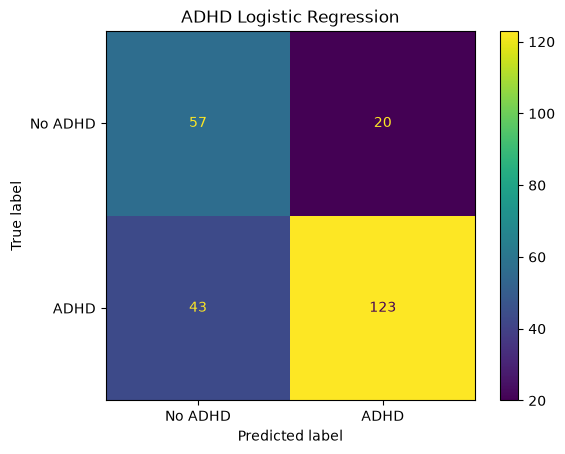

In [43]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=[
        "No ADHD",
        "ADHD"
    ]
)

plt.title(
    "ADHD Logistic Regression"
)

plt.show()

In [44]:
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training:", X_train2.shape)
print("Validation:", X_val.shape)

Training: (776, 27)
Validation: (194, 27)


In [45]:
threshold_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )
    )
])

threshold_model.fit(
    X_train2,
    y_train2
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['Basic_Demos_Enroll_Year','Basic_Demos_Study_Site', 'PreInt_Demos_Fam_Child_Ethnicity',...,'SDQ_SDQ_Peer_Problems', 'SDQ_SDQ_Prosocial','MRI_Track_Age_at_Scan']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the n

In [46]:
y_val_prob = threshold_model.predict_proba(
    X_val
)[:, 1]

y_val_prob[:10]

array([0.71958828, 0.87939283, 0.86073344, 0.16927009, 0.56477808,
       0.98990071, 0.84908789, 0.98463609, 0.59455615, 0.10288259])

In [47]:
thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

threshold_results = []

for threshold in thresholds:

    predictions = (
        y_val_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            predictions
        ),
        "F1": f1_score(
            y_val,
            predictions
        ),
        "Accuracy": accuracy_score(
            y_val,
            predictions
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Precision,Recall,F1,Accuracy
0,0.10,0.758824,0.969925,0.851485,0.768041
1,0.15,0.779141,0.954887,0.858108,0.783505
2,0.20,0.810458,0.932331,0.867133,0.804124
3,0.25,0.840278,0.909774,0.873646,0.819588
4,0.30,0.847826,0.879699,0.863469,0.809278
5,0.35,0.858209,0.864662,0.861423,0.809278
6,0.40,0.862595,0.849624,0.856061,0.804124
7,0.45,0.873016,0.827068,0.849421,0.798969
8,0.50,0.891667,0.804511,0.845850,0.798969
9,0.55,0.886957,0.766917,0.822581,0.773196


In [48]:
good_thresholds = threshold_df[
    threshold_df["Recall"] >= 0.85
]

good_thresholds

,Threshold,Precision,Recall,F1,Accuracy
0,0.10,0.758824,0.969925,0.851485,0.768041
1,0.15,0.779141,0.954887,0.858108,0.783505
2,0.20,0.810458,0.932331,0.867133,0.804124
3,0.25,0.840278,0.909774,0.873646,0.819588
4,0.30,0.847826,0.879699,0.863469,0.809278
5,0.35,0.858209,0.864662,0.861423,0.809278


In [49]:
best_row = good_thresholds.loc[
    good_thresholds["F1"].idxmax()
]

best_row

Threshold    0.250000
Precision    0.840278
Recall       0.909774
F1           0.873646
Accuracy     0.819588
Name: 3, dtype: float64

In [50]:
best_threshold = float(
    best_row["Threshold"]
)

print(
    "Best ADHD screening threshold:",
    best_threshold
)

Best ADHD screening threshold: 0.25000000000000006


In [51]:
final_adhd_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )
    )
])

final_adhd_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['Basic_Demos_Enroll_Year','Basic_Demos_Study_Site', 'PreInt_Demos_Fam_Child_Ethnicity',...,'SDQ_SDQ_Peer_Problems', 'SDQ_SDQ_Prosocial','MRI_Track_Age_at_Scan']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the n

In [52]:
final_prob = final_adhd_model.predict_proba(
    X_test
)[:, 1]

final_pred = (
    final_prob >= best_threshold
).astype(int)

In [53]:
print("FINAL ADHD SCREENING MODEL")
print("--------------------------")

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        final_pred
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        final_pred
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        final_pred
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        final_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        final_prob
    )
    
)

FINAL ADHD SCREENING MODEL
--------------------------
Accuracy: 0.7983539094650206
Precision: 0.8162162162162162
Recall: 0.9096385542168675
F1: 0.8603988603988604
ROC-AUC: 0.8414958535440463


In [54]:
print(
    classification_report(
        y_test,
        final_pred,
        target_names=[
            "No ADHD",
            "ADHD"
        ]
    )
)

              precision    recall  f1-score   support

     No ADHD       0.74      0.56      0.64        77
        ADHD       0.82      0.91      0.86       166

    accuracy                           0.80       243
   macro avg       0.78      0.73      0.75       243
weighted avg       0.79      0.80      0.79       243



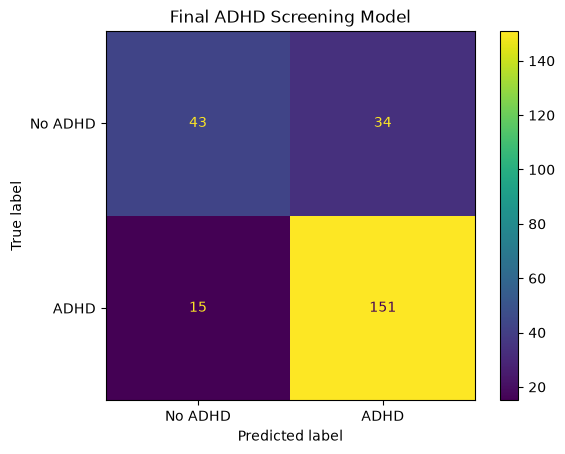

In [55]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_pred,
    display_labels=[
        "No ADHD",
        "ADHD"
    ]
)

plt.title(
    "Final ADHD Screening Model"
)

plt.show()

In [56]:
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

In [57]:
threshold_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

threshold_model.fit(X_train2, y_train2)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['Basic_Demos_Enroll_Year','Basic_Demos_Study_Site', 'PreInt_Demos_Fam_Child_Ethnicity',...,'SDQ_SDQ_Peer_Problems', 'SDQ_SDQ_Prosocial','MRI_Track_Age_at_Scan']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the n

In [58]:
y_val_prob = threshold_model.predict_proba(X_val)[:, 1]

In [59]:
thresholds = np.arange(0.10, 0.91, 0.01)

threshold_results = []

for threshold in thresholds:

    pred = (y_val_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(
            y_val, pred, zero_division=0
        ),
        "Recall": recall_score(y_val, pred),
        "F1": f1_score(y_val, pred)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.768041,0.758824,0.969925,0.851485
1,0.11,0.773196,0.763314,0.969925,0.854305
2,0.12,0.773196,0.766467,0.962406,0.853333
3,0.13,0.778351,0.771084,0.962406,0.856187
4,0.14,0.778351,0.771084,0.962406,0.856187
...,...,...,...,...,...
76,0.86,0.500000,0.928571,0.293233,0.445714
77,0.87,0.489691,0.925000,0.278195,0.427746
78,0.88,0.469072,0.916667,0.248120,0.390533
79,0.89,0.469072,0.941176,0.240602,0.383234


In [60]:
good_thresholds = threshold_df[
    threshold_df["Recall"] >= 0.85
]

good_thresholds.sort_values(
    "F1",
    ascending=False
).head(10)

,Threshold,Accuracy,Precision,Recall,F1
9,0.19,0.814433,0.812903,0.947368,0.875000
15,0.25,0.819588,0.840278,0.909774,0.873646
14,0.24,0.819588,0.840278,0.909774,0.873646
11,0.21,0.814433,0.825503,0.924812,0.872340
7,0.17,0.809278,0.807692,0.947368,0.871972
8,0.18,0.809278,0.807692,0.947368,0.871972
12,0.22,0.814433,0.829932,0.917293,0.871429
16,0.26,0.814433,0.839161,0.902256,0.869565
17,0.27,0.814433,0.843972,0.894737,0.868613
18,0.28,0.814433,0.843972,0.894737,0.868613


In [61]:
best_row = good_thresholds.loc[
    good_thresholds["F1"].idxmax()
]

best_row

Threshold    0.190000
Accuracy     0.814433
Precision    0.812903
Recall       0.947368
F1           0.875000
Name: 9, dtype: float64

In [62]:
best_threshold = float(
    best_row["Threshold"]
)


print("Best threshold:", best_threshold)

Best threshold: 0.18999999999999995


In [63]:
final_prob = adhd_logistic_model.predict_proba(
    X_test
)[:, 1]

final_pred = (
    final_prob >= best_threshold
).astype(int)

In [64]:
print("FULL ADHD MODEL")
print("----------------")

print(
    "Accuracy:",
    accuracy_score(y_test, final_pred)
)

print(
    "Precision:",
    precision_score(y_test, final_pred)
)

print(
    "Recall:",
    recall_score(y_test, final_pred)
)

print(
    "F1:",
    f1_score(y_test, final_pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, final_prob)
)

FULL ADHD MODEL
----------------
Accuracy: 0.8106995884773662
Precision: 0.8092783505154639
Recall: 0.9457831325301205
F1: 0.8722222222222222
ROC-AUC: 0.8407135033641058


In [65]:
print(
    classification_report(
        y_test,
        final_pred,
        target_names=[
            "No ADHD",
            "ADHD"
        ]
    )
)

              precision    recall  f1-score   support

     No ADHD       0.82      0.52      0.63        77
        ADHD       0.81      0.95      0.87       166

    accuracy                           0.81       243
   macro avg       0.81      0.73      0.75       243
weighted avg       0.81      0.81      0.80       243



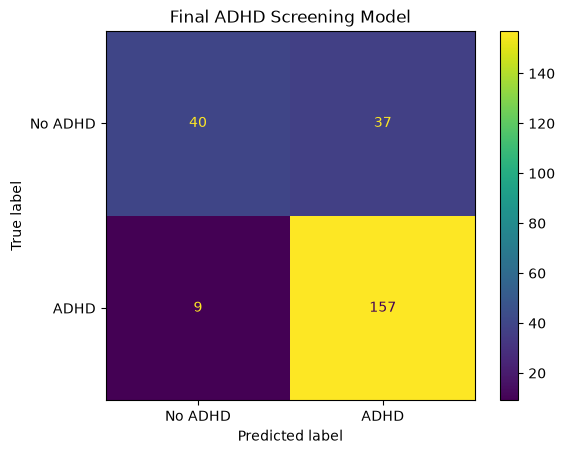

In [66]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_pred,
    display_labels=[
        "No ADHD",
        "ADHD"
    ]
)

plt.title("Final ADHD Screening Model")

plt.show()

In [67]:
app_features = [
    col for col in X.columns
    if col.startswith("APQ_")
    or col.startswith("SDQ_")
]

print("App features:")
print(app_features)

print()
print("Number of features:", len(app_features))

App features:
['APQ_P_APQ_P_CP', 'APQ_P_APQ_P_ID', 'APQ_P_APQ_P_INV', 'APQ_P_APQ_P_OPD', 'APQ_P_APQ_P_PM', 'APQ_P_APQ_P_PP', 'SDQ_SDQ_Conduct_Problems', 'SDQ_SDQ_Difficulties_Total', 'SDQ_SDQ_Emotional_Problems', 'SDQ_SDQ_Externalizing', 'SDQ_SDQ_Generating_Impact', 'SDQ_SDQ_Hyperactivity', 'SDQ_SDQ_Internalizing', 'SDQ_SDQ_Peer_Problems', 'SDQ_SDQ_Prosocial']

Number of features: 15


In [68]:
X_app = adhd_data[app_features]

y_app = adhd_data["ADHD_Outcome"]

print(X_app.shape)
print(y_app.shape)

(1213, 15)
(1213,)


In [69]:
X_app_train, X_app_test, y_app_train, y_app_test = train_test_split(
    X_app,
    y_app,
    test_size=0.20,
    random_state=42,
    stratify=y_app
)

In [70]:
app_preprocessor = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    )
])

In [71]:
app_model = Pipeline([
    (
        "preprocessor",
        app_preprocessor
    ),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )
    )
])

app_model.fit(
    X_app_train,
    y_app_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['APQ_P_APQ_P_CP','APQ_P_APQ_P_ID','APQ_P_APQ_P_INV',..., 'SDQ_SDQ_Internalizing','SDQ_SDQ_Peer_Problems','SDQ_SDQ_Prosocial']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer

In [72]:
app_pred = app_model.predict(
    X_app_test
)

app_prob = app_model.predict_proba(
    X_app_test
)[:, 1]

In [73]:
print("APP-FRIENDLY MODEL")
print("------------------")

print(
    "Accuracy:",
    accuracy_score(
        y_app_test,
        app_pred
    )
)

print(
    "Precision:",
    precision_score(
        y_app_test,
        app_pred
    )
)

print(
    "Recall:",
    recall_score(
        y_app_test,
        app_pred
    )
)

print(
    "F1:",
    f1_score(
        y_app_test,
        app_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_app_test,
        app_prob
    )
)


APP-FRIENDLY MODEL
------------------
Accuracy: 0.7613168724279835
Precision: 0.8698630136986302
Recall: 0.7650602409638554
F1: 0.8141025641025641
ROC-AUC: 0.8317164762947895


In [74]:
X_app_train2, X_app_val, y_app_train2, y_app_val = train_test_split(
    X_app_train,
    y_app_train,
    test_size=0.20,
    random_state=42,
    stratify=y_app_train
)

In [75]:
app_threshold_model = Pipeline([
    (
        "preprocessor",
        app_preprocessor
    ),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )
    )
])

app_threshold_model.fit(
    X_app_train2,
    y_app_train2
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['APQ_P_APQ_P_CP','APQ_P_APQ_P_ID','APQ_P_APQ_P_INV',..., 'SDQ_SDQ_Internalizing','SDQ_SDQ_Peer_Problems','SDQ_SDQ_Prosocial']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer

In [77]:
app_val_prob = app_threshold_model.predict_proba(
    X_app_val
)[:, 1]

In [78]:
app_thresholds = np.arange(
    0.10,
    0.91,
    0.01
)

app_threshold_results = []

for threshold in app_thresholds:

    predictions = (
        app_val_prob >= threshold
    ).astype(int)

    app_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_app_val,
            predictions
        ),
        "Precision": precision_score(
            y_app_val,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_app_val,
            predictions
        ),
        "F1": f1_score(
            y_app_val,
            predictions
        )
    })

app_threshold_df = pd.DataFrame(
    app_threshold_results
)

app_threshold_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.773196,0.754286,0.992481,0.857143
1,0.11,0.778351,0.764706,0.977444,0.858086
2,0.12,0.783505,0.769231,0.977444,0.860927
3,0.13,0.798969,0.786585,0.969925,0.868687
4,0.14,0.814433,0.801242,0.969925,0.877551
...,...,...,...,...,...
76,0.86,0.474227,0.969697,0.240602,0.385542
77,0.87,0.453608,0.965517,0.210526,0.345679
78,0.88,0.438144,0.961538,0.187970,0.314465
79,0.89,0.427835,0.958333,0.172932,0.292994


In [79]:
good_app_thresholds = app_threshold_df[
    app_threshold_df["Recall"] >= 0.85
]

good_app_thresholds.sort_values(
    "F1",
    ascending=False
).head(10)

,Threshold,Accuracy,Precision,Recall,F1
7,0.17,0.835052,0.821656,0.969925,0.889655
8,0.18,0.829897,0.820513,0.962406,0.885813
6,0.16,0.824742,0.811321,0.969925,0.883562
5,0.15,0.824742,0.811321,0.969925,0.883562
9,0.19,0.824742,0.819355,0.954887,0.881944
10,0.20,0.824742,0.819355,0.954887,0.881944
17,0.27,0.829897,0.842466,0.924812,0.881720
19,0.29,0.829897,0.842466,0.924812,0.881720
18,0.28,0.829897,0.842466,0.924812,0.881720
13,0.23,0.824742,0.827815,0.939850,0.880282


In [80]:
best_app_row = good_app_thresholds.loc[
    good_app_thresholds["F1"].idxmax()
]

best_app_row

Threshold    0.170000
Accuracy     0.835052
Precision    0.821656
Recall       0.969925
F1           0.889655
Name: 7, dtype: float64

In [81]:
best_app_threshold = float(
    best_app_row["Threshold"]
)

print(
    "Best App threshold:",
    best_app_threshold
)

Best App threshold: 0.16999999999999998


In [82]:
final_app_model = Pipeline([
    (
        "preprocessor",
        app_preprocessor
    ),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )
    )
])

final_app_model.fit(
    X_app_train,
    y_app_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['APQ_P_APQ_P_CP','APQ_P_APQ_P_ID','APQ_P_APQ_P_INV',..., 'SDQ_SDQ_Internalizing','SDQ_SDQ_Peer_Problems','SDQ_SDQ_Prosocial']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer

In [83]:
final_app_prob = final_app_model.predict_proba(
    X_app_test
)[:, 1]

final_app_pred = (
    final_app_prob >= best_app_threshold
).astype(int)

In [84]:
print("FINAL APP-FRIENDLY ADHD MODEL")
print("-----------------------------")

print(
    "Accuracy:",
    accuracy_score(
        y_app_test,
        final_app_pred
    )
)

print(
    "Precision:",
    precision_score(
        y_app_test,
        final_app_pred
    )
)

print(
    "Recall:",
    recall_score(
        y_app_test,
        final_app_pred
    )
)

print(
    "F1:",
    f1_score(
        y_app_test,
        final_app_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_app_test,
        final_app_prob
    )
)

FINAL APP-FRIENDLY ADHD MODEL
-----------------------------
Accuracy: 0.7818930041152263
Precision: 0.7703349282296651
Recall: 0.9698795180722891
F1: 0.8586666666666667
ROC-AUC: 0.8317164762947895


In [85]:
print(
    classification_report(
        y_app_test,
        final_app_pred,
        target_names=[
            "No ADHD",
            "ADHD"
        ]
    )
)

              precision    recall  f1-score   support

     No ADHD       0.85      0.38      0.52        77
        ADHD       0.77      0.97      0.86       166

    accuracy                           0.78       243
   macro avg       0.81      0.67      0.69       243
weighted avg       0.80      0.78      0.75       243



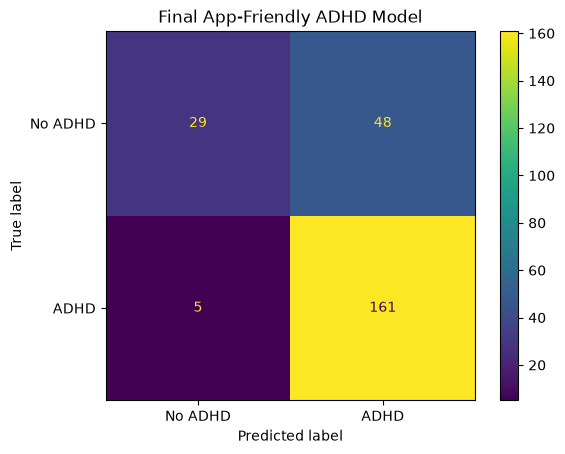

In [87]:
ConfusionMatrixDisplay.from_predictions(
    y_app_test,
    final_app_pred,
    display_labels=[
        "No ADHD",
        "ADHD"
    ]
)

plt.title(
    "Final App-Friendly ADHD Model"
)

plt.show()

In [88]:
import json

app_preprocessor_fitted = (
    final_app_model.named_steps[
        "preprocessor"
    ]
)

app_imputer = (
    app_preprocessor_fitted.named_steps[
        "imputer"
    ]
)

app_scaler = (
    app_preprocessor_fitted.named_steps[
        "scaler"
    ]
)

app_logistic = (
    final_app_model.named_steps[
        "model"
    ]
)

flutter_adhd_model = {
    "feature_names": app_features,

    "imputer_medians":
        app_imputer.statistics_.tolist(),

    "scaler_mean":
        app_scaler.mean_.tolist(),

    "scaler_scale":
        app_scaler.scale_.tolist(),

    "coefficients":
        app_logistic.coef_[0].tolist(),

    "intercept":
        float(app_logistic.intercept_[0]),

    "threshold":
        float(best_app_threshold)
}

with open(
    "adhd_flutter_model.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        flutter_adhd_model,
        file,
        indent=2
    )

print(
    "ADHD Flutter model exported successfully."
)

print(
    "Features:",
    len(app_features)
)

print(
    "Threshold:",
    best_app_threshold
)

ADHD Flutter model exported successfully.
Features: 15
Threshold: 0.16999999999999998
